### Models of Stock Return

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
ms = pd.read_csv("data/microsoft.csv")
ms.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-12-31,46.730000,47.439999,46.450001,46.450001,42.848763,21552500
1,2015-01-02,46.660000,47.419998,46.540001,46.759998,43.134731,27913900
2,2015-01-05,46.369999,46.730000,46.250000,46.330002,42.738068,39673900
3,2015-01-06,46.380001,46.750000,45.540001,45.650002,42.110783,36447900
4,2015-01-07,45.980000,46.459999,45.490002,46.230000,42.645817,29114100


### Distribution of Log Return

In [3]:
# Let's play around with MS data by calculating the log daily return
ms['LogReturn'] = np.log(ms['Close']).shift(-1) - np.log(ms['Close'])

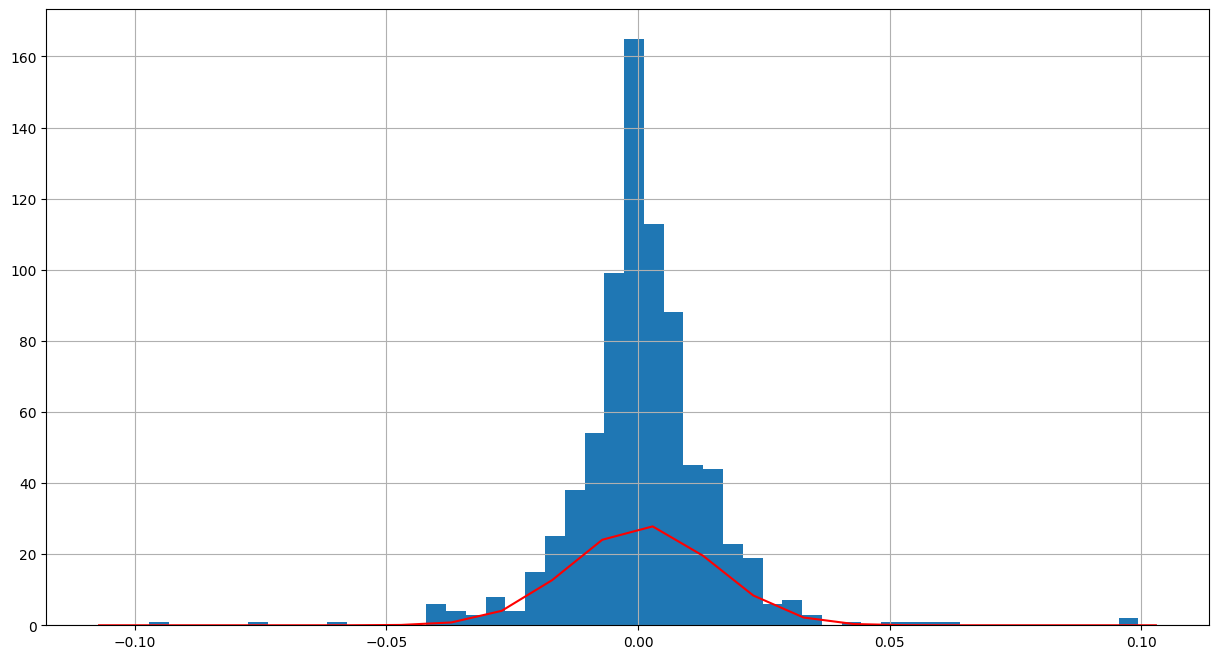

In [5]:
# Plot a histogram to show the distribution of log return of Microsoft's stock.
# You can see it is very close to a normal distribution
from scipy.stats import norm
mu = ms['LogReturn'].mean()
sigma = ms['LogReturn'].std(ddof=1)

density = pd.DataFrame()
density['x'] = np.arange(ms['LogReturn'].min()-0.01, ms['LogReturn'].max()+0.01, 0.01)
density['pdf'] = norm.pdf(density['x'], mu, sigma)

ms['LogReturn'].hist(bins=50, figsize=(15,8))
plt.plot(density['x'], density['pdf'], color='red')
plt.show()

### Calculate the probability of the stock price will drop over a certain percentage in a day

In [6]:
# probability that the stock price of microsoft will drop over 5% in a day
prob_return1 = norm.cdf(-0.05, mu, sigma)
print(f'The probability is {prob_return1}')

The probability is 0.00017118482608677866


In [7]:
# Now is your turn, calculate the probabilty that the stock price of Microsoft will drop over 10% in a day.
prob_return1 = None
print(f'The probabilty is {prob_return1}')

The probabilty is None


### Calculate the probability of the stock price will drop over a certain percentage in a year

In [9]:
# drop over 40% in 220 days (1 year of Stock market)
mu220 = 220*mu
sigma220 = (220**0.5)*sigma
print(f'The probability of dropping over 40% in 220 days is {norm.cdf(-0.4, mu220, sigma220)}')

The probability of dropping over 40% in 220 days is 0.0029123633133305506


In [12]:
# drop over 20% in 220 days
mu220 = 220*mu
sigma220 = (220**0.5)*sigma
drop20 = norm.cdf(-0.2, mu220, sigma220)
print(f'The probability of dropping over 20% in 220 days is {drop20}')

The probability of dropping over 20% in 220 days is 0.03535237727490914


### Calculate Value at Risk (VaR)

In [13]:
# Value at Risk (VaR)
VaR = norm.ppf(0.05, mu, sigma)
print(f'Single day value at risk: {VaR}')

Single day value at risk: -0.02252336240706501


In [14]:
# Quantile
# 5% Quantile
print(f'5% quantile: {norm.ppf(0.05,mu,sigma)}')
# 95% Quantile
print(f'95% quantile: {norm.ppf(0.95,mu,sigma)}')

5% quantile: -0.02252336240706501
95% quantile: 0.02416382537931104


In [15]:
# This is your turn to calculate the 25% and 75% Quantile of the return
# 25% quantile
q25 = norm.ppf(0.25, mu, sigma)
print(f'25% quantile: {q25}')
# 75% quantile
q75 = norm.ppf(0.75, mu, sigma)
print(f'75% quantile: {q75}')

25% quantile: -0.008752057838414963
75% quantile: 0.01039252081066101
